# 🏨 Phase 2 — Complaint Categorization
**Goal:** Automatically classify negative reviews into hotel departments/categories  
**Categories:** Cleanliness · Service · Food & Beverage · Noise · Location · Value · Room · Facilities

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv(r"C:\Users\dimma\OneDrive\Υπολογιστής\Hotel 515\Hotel_Reviews.csv")

# Keep only reviews with negative text
df['Negative_Review'] = df['Negative_Review'].replace('No Negative', '')
df['Hotel_Country'] = df['Hotel_Address'].apply(lambda x: x.split()[-1])

complaints_df = df[df['Negative_Review'].str.len() > 10].copy()
complaints_df['neg_lower'] = complaints_df['Negative_Review'].str.lower()

print(f'✅ Reviews with complaints: {len(complaints_df):,} out of {len(df):,} total')

✅ Reviews with complaints: 353,149 out of 515,738 total


## 3. Keyword-Based Categorization

In [3]:
# Define keyword dictionary per department (Quality Coordinator perspective)
CATEGORY_KEYWORDS = {
    'Cleanliness': [
        'dirty', 'clean', 'stain', 'dust', 'smell', 'odor', 'mold', 'hygiene',
        'filthy', 'unhygienic', 'bathroom', 'toilet', 'sheets', 'towels', 'bugs'
    ],
    'Service': [
        'staff', 'rude', 'unfriendly', 'unhelpful', 'slow', 'service', 'reception',
        'front desk', 'check-in', 'checkout', 'ignored', 'attitude', 'polite', 'wait'
    ],
    'Food & Beverage': [
        'breakfast', 'food', 'restaurant', 'bar', 'dinner', 'lunch', 'meal',
        'buffet', 'coffee', 'taste', 'cold food', 'menu', 'overpriced food'
    ],
    'Noise': [
        'noise', 'noisy', 'loud', 'party', 'music', 'street', 'construction',
        'neighbors', 'thin walls', 'soundproof', 'disturb', 'sleep'
    ],
    'Room': [
        'room', 'bed', 'mattress', 'pillow', 'small room', 'window', 'view',
        'dark', 'cramped', 'outdated', 'furniture', 'closet', 'wardrobe'
    ],
    'Location': [
        'location', 'far', 'distance', 'transport', 'parking', 'access',
        'neighborhood', 'area', 'dangerous', 'remote', 'hard to find'
    ],
    'Value': [
        'expensive', 'overpriced', 'price', 'value', 'cost', 'worth',
        'cheap', 'rip off', 'not worth', 'hidden charges', 'fee'
    ],
    'Facilities': [
        'pool', 'gym', 'wifi', 'internet', 'elevator', 'lift', 'spa',
        'air conditioning', 'heating', 'tv', 'safe', 'broken', 'not working'
    ]
}

def categorize_complaint(text):
    """Returns a list of matching categories for a complaint"""
    categories = []
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in text for kw in keywords):
            categories.append(category)
    return categories if categories else ['Other']

complaints_df['categories'] = complaints_df['neg_lower'].apply(categorize_complaint)
complaints_df['primary_category'] = complaints_df['categories'].apply(lambda x: x[0])

print('✅ Categorization complete')
print(complaints_df['primary_category'].value_counts())

✅ Categorization complete
primary_category
Room               74379
Cleanliness        56988
Service            56463
Food & Beverage    55135
Other              55110
Noise              21200
Facilities         13244
Location           13090
Value               7540
Name: count, dtype: int64


## 4. Complaint Volume per Category

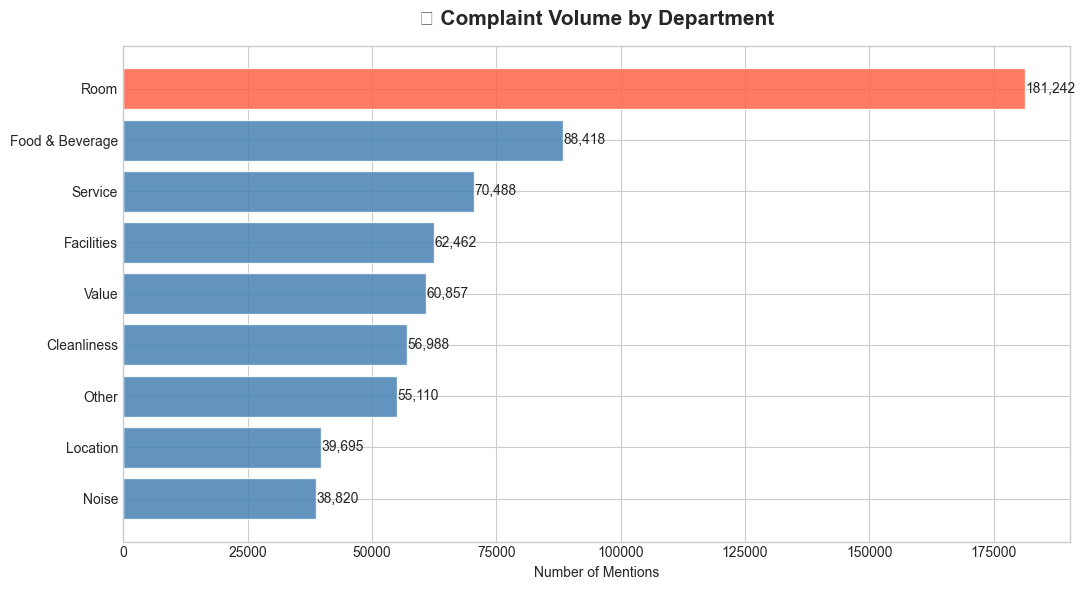

In [6]:
# Explode multi-label categories
all_categories = [cat for cats in complaints_df['categories'] for cat in cats]
cat_counts = pd.Series(Counter(all_categories)).sort_values(ascending=True)

colors = ['tomato' if v == cat_counts.max() else 'steelblue' for v in cat_counts.values]

plt.figure(figsize=(11, 6))
bars = plt.barh(cat_counts.index, cat_counts.values, color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, cat_counts.values):
    plt.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)

plt.title('📊 Complaint Volume by Department', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Mentions')
plt.tight_layout()

plt.show()

## 5. Average Score per Complaint Category

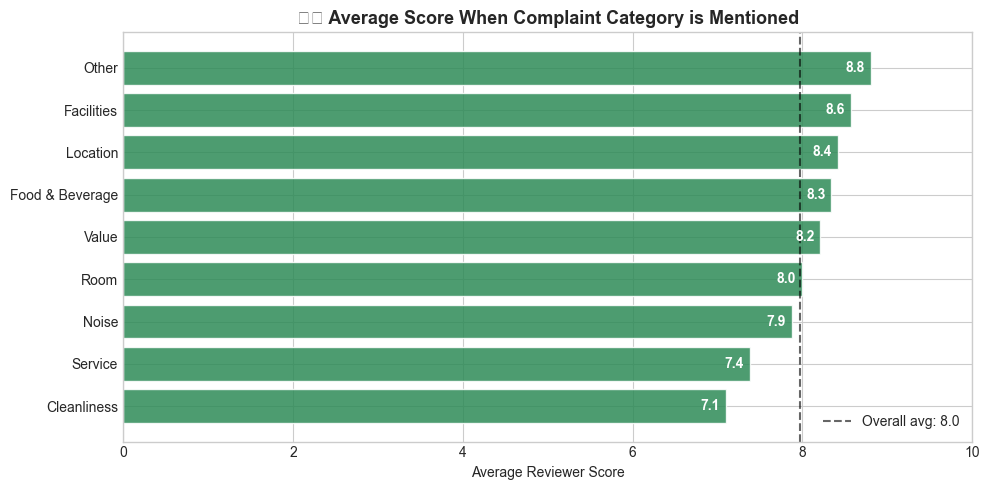

💡 Lower score = this complaint has highest negative impact on guest satisfaction


In [7]:
# Average reviewer score for each complaint category
cat_score = complaints_df.groupby('primary_category')['Reviewer_Score'].mean().sort_values()

colors = ['tomato' if v < 6 else 'orange' if v < 7 else 'seagreen' for v in cat_score.values]

plt.figure(figsize=(10, 5))
bars = plt.barh(cat_score.index, cat_score.values, color=colors, alpha=0.85)
plt.axvline(complaints_df['Reviewer_Score'].mean(), color='black',
            linestyle='--', alpha=0.6, label=f'Overall avg: {complaints_df["Reviewer_Score"].mean():.1f}')

for bar, val in zip(bars, cat_score.values):
    plt.text(val - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color='white', fontweight='bold')

plt.title('⚠️ Average Score When Complaint Category is Mentioned', fontsize=13, fontweight='bold')
plt.xlabel('Average Reviewer Score')
plt.xlim(0, 10)
plt.legend()
plt.tight_layout()

plt.show()
print('💡 Lower score = this complaint has highest negative impact on guest satisfaction')

## 6. Complaint Heatmap (Category × Country)

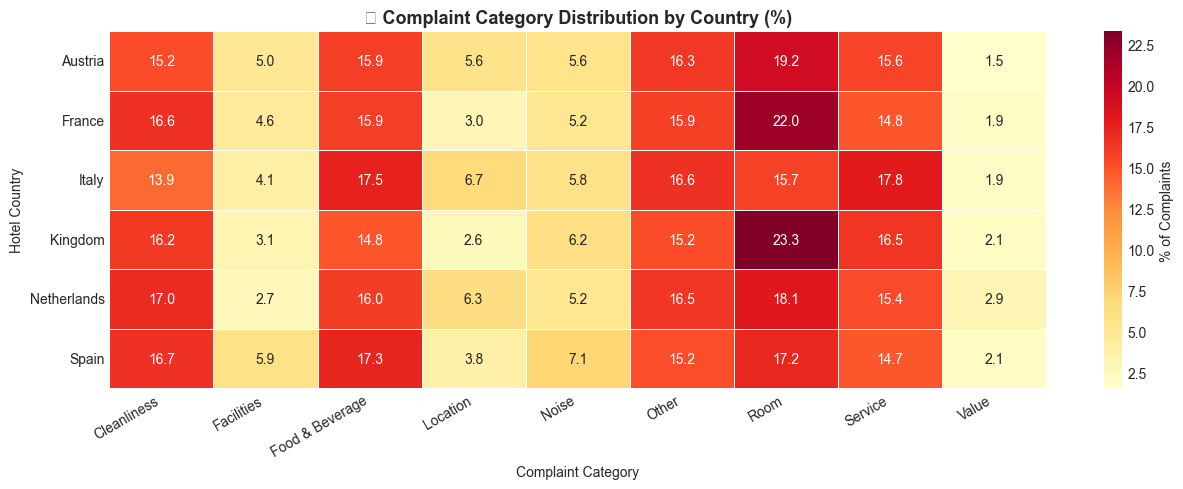

In [8]:
heatmap_data = complaints_df.groupby(['Hotel_Country', 'primary_category']).size().unstack(fill_value=0)

# Normalize by row (% of complaints per country)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(13, 5))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of Complaints'})
plt.title('🌍 Complaint Category Distribution by Country (%)', fontsize=13, fontweight='bold')
plt.xlabel('Complaint Category')
plt.ylabel('Hotel Country')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

## 7. Top 20 Most Frequent Complaint Keywords

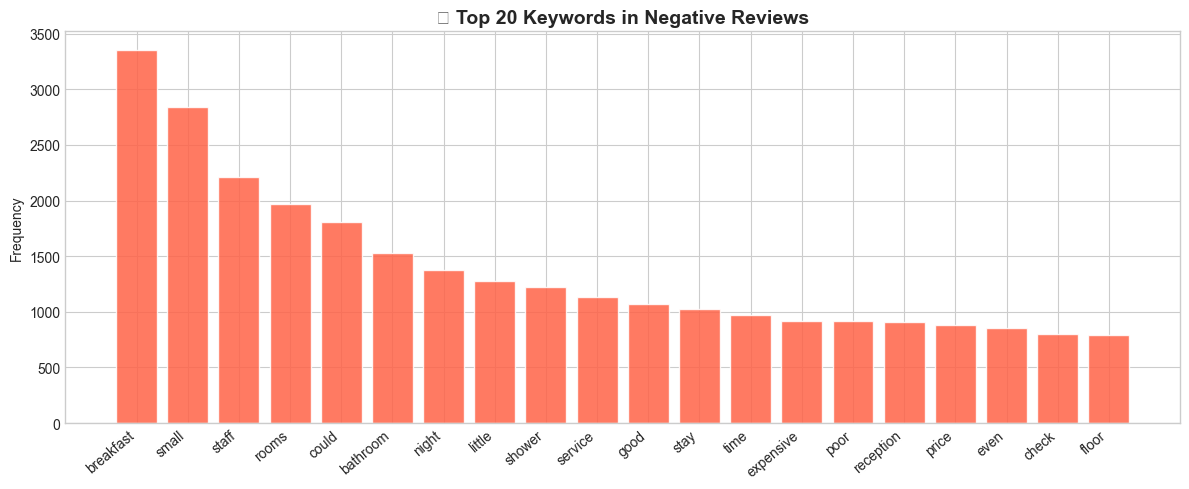

In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
extra_stops = {'hotel', 'room', 'nothing', 'no', 'not', 'also', 'would', 'like', 'really'}
stop_words.update(extra_stops)

# Sample for speed
sample_text = ' '.join(complaints_df['Negative_Review'].dropna().sample(min(20000, len(complaints_df)), random_state=42))
tokens = word_tokenize(sample_text.lower())
filtered = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]
word_freq = Counter(filtered).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='tomato', alpha=0.85, edgecolor='white')
plt.title('🔑 Top 20 Keywords in Negative Reviews', fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()

## 8. Export Categorized Dataset

In [12]:
export_cols = ['Hotel_Name', 'Hotel_Country', 'Reviewer_Score', 'Review_Date',
               'Negative_Review', 'primary_category', 'categories']



print('✅ Exported: complaints_categorized.csv')
print()
print('Category breakdown:')
print(complaints_df['primary_category'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('✅ Phase 2 Complete! → Proceed to 03_Sentiment_Analysis.ipynb')

✅ Exported: complaints_categorized.csv

Category breakdown:
primary_category
Room               21.1
Cleanliness        16.1
Service            16.0
Food & Beverage    15.6
Other              15.6
Noise               6.0
Facilities          3.8
Location            3.7
Value               2.1

✅ Phase 2 Complete! → Proceed to 03_Sentiment_Analysis.ipynb
